<a href="https://colab.research.google.com/github/Alok224/Celebal_Weekly_Assignments/blob/main/Week4_Alok_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification using ANN and CNN

**Objective:** Build and compare image classification models — ANN, CNN, and an Augmented CNN — on the CIFAR-10 dataset.

**About CIFAR-10:** It contains 60,000 colour images of size 32×32 pixels across 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck). The dataset is split into 50,000 training and 10,000 test images.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [4]:
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()t

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Training data shape :", x_train.shape)
print("Testing data shape  :", x_test.shape)
print("Number of classes   :", len(class_names))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape : (50000, 32, 32, 3)
Testing data shape  : (10000, 32, 32, 3)
Number of classes   : 10


##  Visualize Sample Images

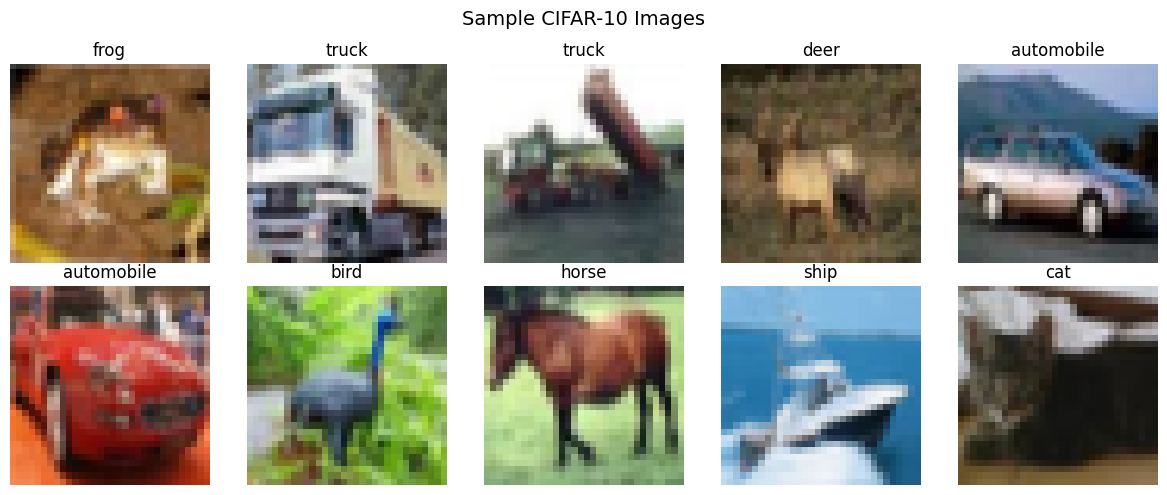

In [5]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Display sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()

## ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = keras.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='ANN')

ann_model.summary()

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

ann_history = ann_model.fit(x_train, y_train,
                             epochs=10,
                             batch_size=64,
                             validation_split=0.1,
                             verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.2466 - loss: 2.0425 - val_accuracy: 0.3054 - val_loss: 1.8736
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.2912 - loss: 1.9248 - val_accuracy: 0.3192 - val_loss: 1.8855
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3044 - loss: 1.8775 - val_accuracy: 0.3436 - val_loss: 1.8185
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3201 - loss: 1.8444 - val_accuracy: 0.3538 - val_loss: 1.7935
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.3327 - loss: 1.8215 - val_accuracy: 0.3766 - val_loss: 1.7822
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3360 - loss: 1.8081 - val_accuracy: 0.3840 - val_loss: 1.7709
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3480 - loss: 1.7921 - val_accuracy: 0.3522 - val_loss: 1.8054
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3532 - loss: 1.7800 - 

In [7]:
ann_loss, ann_acc = ann_model.evaluate(x_test, y_test, verbose=0)
print(f"ANN  →  Test Loss: {ann_loss:.4f}  |  Test Accuracy: {ann_acc*100:.2f}%")

ANN  →  Test Loss: 1.6968  |  Test Accuracy: 39.62%


# Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN')

cnn_model.summary()

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_history = cnn_model.fit(x_train, y_train,
                             epochs=10,
                             batch_size=64,
                             validation_split=0.1,
                             verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,178 (4.09 MB)

 Trainable params: 1,070,986 (4.09 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 117s 163ms/step - accuracy: 0.4554 - loss: 1.5582 - val_accuracy: 0.4712 - val_loss: 1.5533
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 162ms/step - accuracy: 0.5761 - loss: 1.1927 - val_accuracy: 0.5332 - val_loss: 1.3498
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 161ms/step - accuracy: 0.6417 - loss: 1.0136 - val_accuracy: 0.6638 - val_loss: 0.9677
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 162ms/step - accuracy: 0.6848 - loss: 0.8982 - val_accuracy: 0.6656 - val_loss: 0.9400
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 161ms/step - accuracy: 0.7193 - loss: 0.8000 - val_accuracy: 0.6750 - val_loss: 0.9550
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 157ms/step - accuracy: 0.7485 - loss: 0.7152 - val_accuracy: 0.6852 - val_loss: 0.9186
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.7772 - loss: 0.6331 - val_accuracy: 0.7070 - val_loss: 0.8523
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 113s 160ms/step - accuracy: 0.7998 -

In [9]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"CNN  →  Test Loss: {cnn_loss:.4f}  |  Test Accuracy: {cnn_acc*100:.2f}%")
print(f"\nImprovement over ANN: +{(cnn_acc - ann_acc)*100:.2f}%")

CNN  →  Test Loss: 1.0312  |  Test Accuracy: 70.43%

Improvement over ANN: +30.81%


## Compare Learning Curves

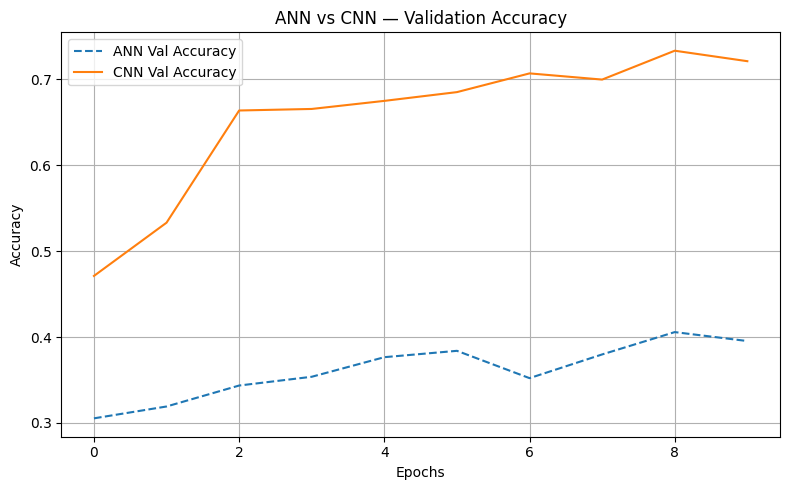

In [10]:
# Validation Accuracy: ANN vs CNN
plt.figure(figsize=(8, 5))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Accuracy', linestyle='--')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy')
plt.title('ANN vs CNN — Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='augmentation')

aug_cnn_model = keras.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='Augmented_CNN')

aug_cnn_model.summary()

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

aug_history = aug_cnn_model.fit(x_train, y_train,
                                 epochs=20,
                                 batch_size=64,
                                 validation_split=0.1,
                                 callbacks=[early_stop],
                                 verbose=1)

Model: "Augmented_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 178s 246ms/step - accuracy: 0.3619 - loss: 1.7942 - val_accuracy: 0.4682 - val_loss: 1.4394
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 242ms/step - accuracy: 0.4791 - loss: 1.4623 - val_accuracy: 0.5482 - val_loss: 1.2490
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 170s 242ms/step - accuracy: 0.5315 - loss: 1.3237 - val_accuracy: 0.6008 - val_loss: 1.1765
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 242ms/step - accuracy: 0.5662 - loss: 1.2295 - val_accuracy: 0.6430 - val_loss: 1.0269
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 242ms/step - accuracy: 0.5934 - loss: 1.1648 - val_accuracy: 0.6550 - val_loss: 1.0053
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 171s 243ms/step - accuracy: 0.6148 - loss: 1.1084 - val_accuracy: 0.6178 - val_loss: 1.1282
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 200s 240ms/step - accuracy: 0.6289 - loss: 1.0639 - val_accuracy: 0.6678 - val_loss: 0.9437
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 169s 240ms/step - accuracy: 0.6481 -

In [12]:
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"Augmented CNN  →  Test Loss: {aug_loss:.4f}  |  Test Accuracy: {aug_acc*100:.2f}%")

Augmented CNN  →  Test Loss: 0.7684  |  Test Accuracy: 73.81%


# Final Comparison Table

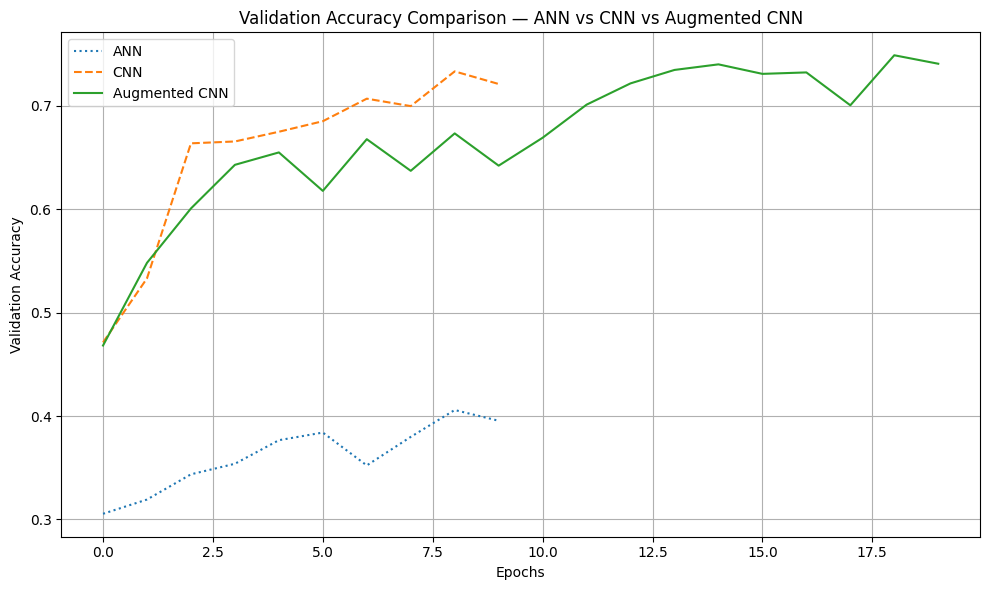


Final Test Accuracies
  ANN           : 39.62%
  CNN           : 70.43%
  Augmented CNN : 73.81%


In [13]:
ann_val = ann_history.history['val_accuracy']
cnn_val = cnn_history.history['val_accuracy']
aug_val = aug_history.history['val_accuracy']

plt.figure(figsize=(10, 6))
plt.plot(ann_val, label='ANN', linestyle=':')
plt.plot(cnn_val, label='CNN', linestyle='--')
plt.plot(aug_val, label='Augmented CNN')
plt.title('Validation Accuracy Comparison — ANN vs CNN vs Augmented CNN')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nFinal Test Accuracies")
print(f"  ANN           : {ann_acc*100:.2f}%")
print(f"  CNN           : {cnn_acc*100:.2f}%")
print(f"  Augmented CNN : {aug_acc*100:.2f}%")

**Key Observations:**

- **ANN** treats pixel values as independent features and ignores spatial structure, which leads to lower accuracy on image data.
- **CNN** uses convolutional filters to capture local patterns (edges, textures, shapes) and spatial hierarchies, giving a significant accuracy boost over ANN.
- **Augmented CNN** adds data augmentation (flips, rotations, zoom) and deeper filter stacks (32 → 64 → 128), which reduces overfitting and improves generalisation.
- EarlyStopping during augmented CNN training prevented unnecessary epochs and helped restore the best-performing weights.
- CNNs are fundamentally better suited for image classification tasks because they exploit spatial locality and parameter sharing, which fully connected layers cannot do.